In [1]:
!pip install seaborn

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import load_subsample_indices
from src.preprocessing import (
    preprocess_data, EXCLUDED_COLUMNS, FULL_FEATURE_SET,
    CATEGORICAL_FEATURES, NUMERICAL_FEATURES, RARE_THRESHOLD,
)

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40)

DATA_PATH = "../data/hotel_bookings_course_release_v1.csv"
INDICES_PATH = "../data/subsample_indices_v1_n30000_seed12345.txt"

df_full = pd.read_csv(DATA_PATH)
indices = load_subsample_indices(INDICES_PATH)
df = df_full.iloc[indices].reset_index(drop=True)

print(f"Full dataset : {df_full.shape}")
print(f"Subsample    : {df.shape}")


Full dataset : (119390, 32)
Subsample    : (30000, 32)


In [3]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
1,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
3,Resort Hotel,0,68,2015,July,27,1,0,4,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,D,E,0,No Deposit,240.0,NaN,0,Transient,97.0,0,3,Check-Out,2015-07-05
4,Resort Hotel,0,37,2015,July,27,1,0,4,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,8.0,NaN,0,Contract,97.5,0,0,Check-Out,2015-07-05


## 1. Subsample Representativeness


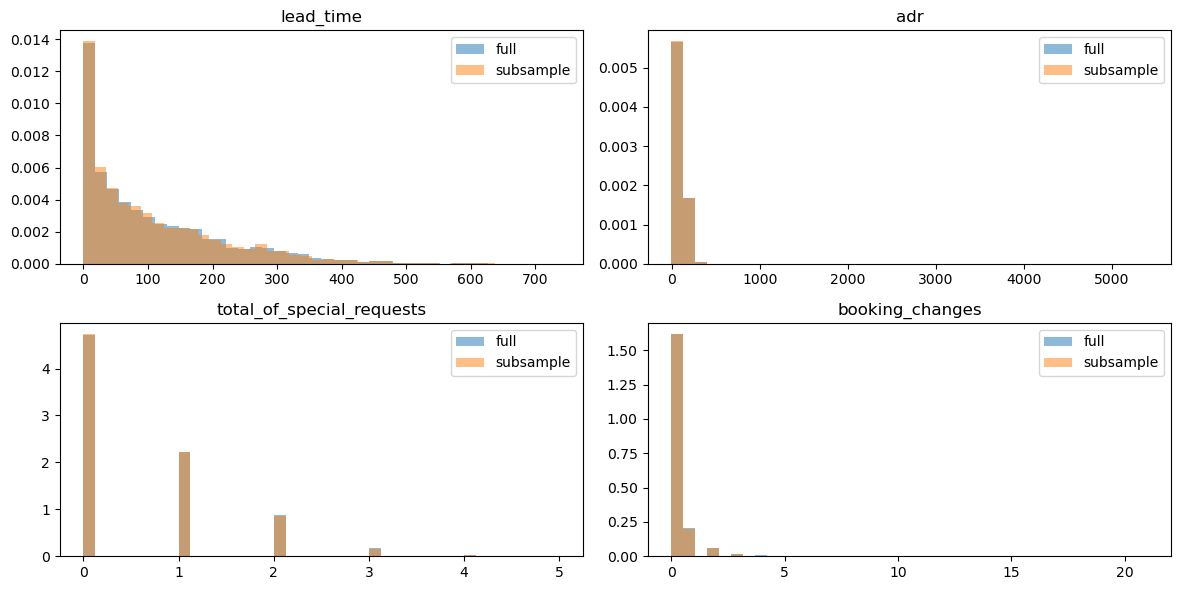

Subsample means vs full means:
                             full  subsample
lead_time                  104.01     103.80
adr                        101.83     101.83
total_of_special_requests    0.57       0.56
booking_changes              0.22       0.22


In [4]:
key_nums = ["lead_time", "adr", "total_of_special_requests", "booking_changes"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flat, key_nums):
    ax.hist(df_full[col].dropna(), bins=40, alpha=0.5, label="full", density=True)
    ax.hist(df[col].dropna(), bins=40, alpha=0.5, label="subsample", density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()
print("Subsample means vs full means:")
print(pd.DataFrame({
    "full": df_full[key_nums].mean(),
    "subsample": df[key_nums].mean(),
}).round(2))


## 2. Missing Value Audit

In [5]:
snap = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
}).sort_values("pct_missing", ascending=False)
print(snap[snap["n_missing"] > 0])


            dtype  n_missing  pct_missing  n_unique
company   float64      28343        94.48       238
agent     float64       4028        13.43       264
country    object        116         0.39       140
children  float64          1         0.00         5


### Imputation decisions

- `children`: fill with 0 (no children assumed when missing)
- `country`: not in feature set, excluded
- All other feature-set columns: no missing values in the subsample


## 3. Feature Distributions


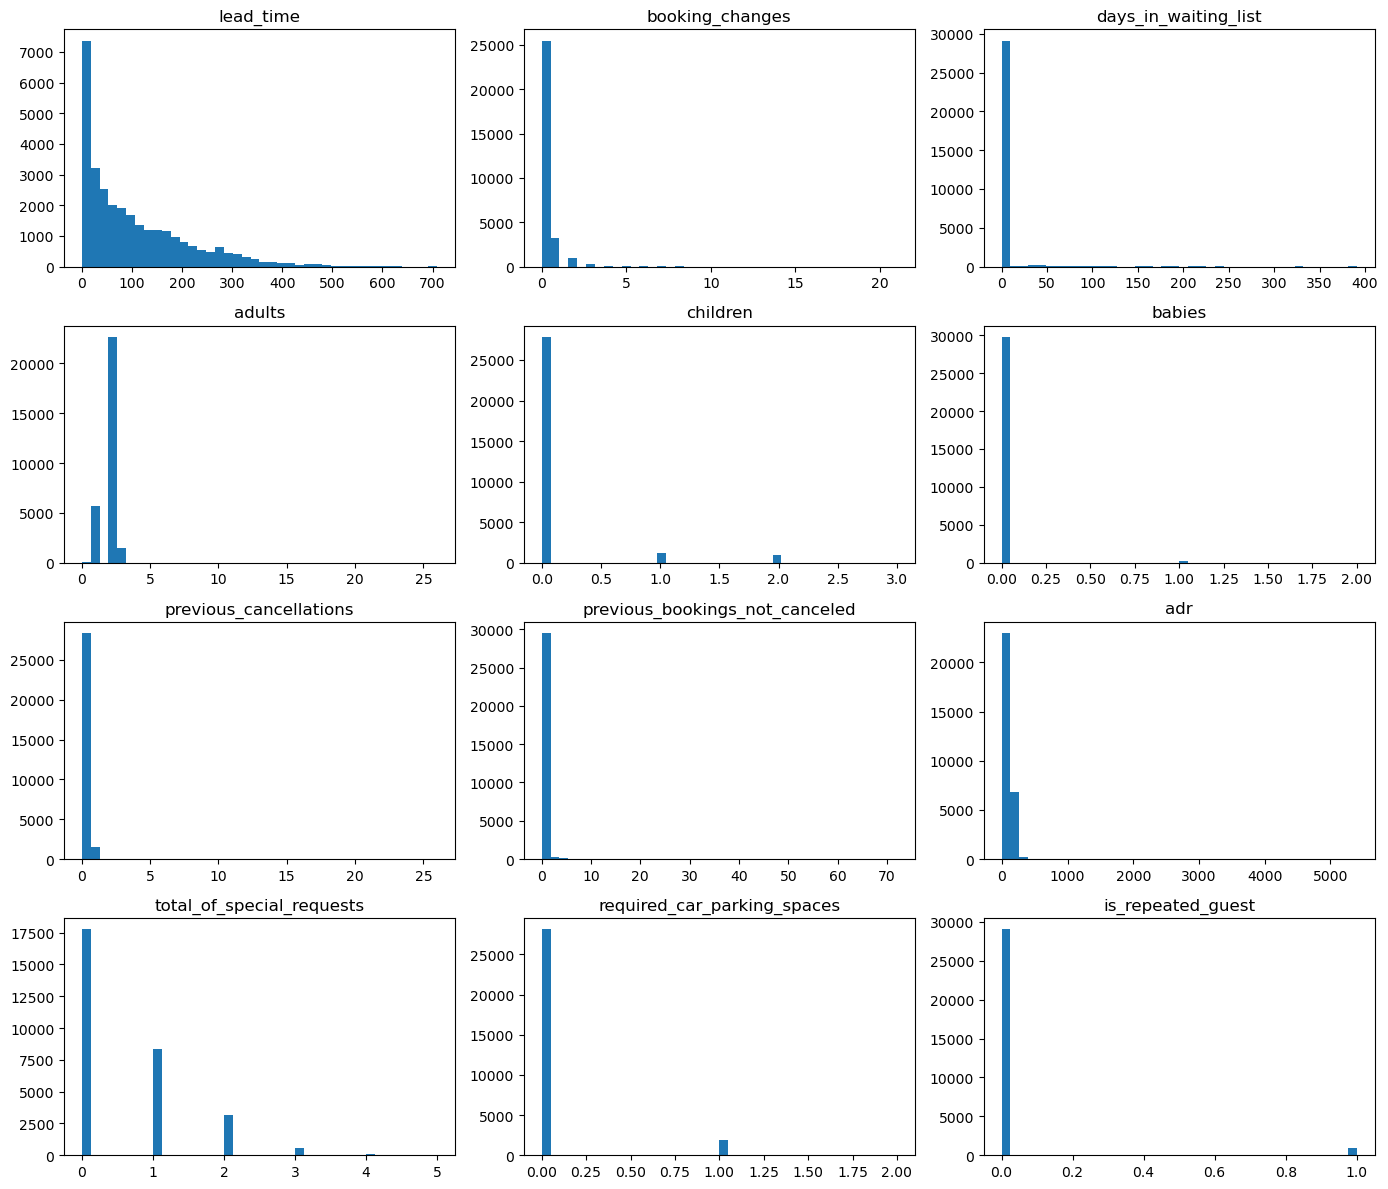

Skewness (|>1| → consider robust scaling):
adr                               27.68
previous_bookings_not_canceled    25.20
previous_cancellations            22.78
days_in_waiting_list              12.23
babies                            11.71
booking_changes                    6.29
adults                             6.21
is_repeated_guest                  5.32
children                           4.02
required_car_parking_spaces        3.63
lead_time                          1.35
total_of_special_requests          1.34
dtype: float64


In [6]:
num_features = [c for c in NUMERICAL_FEATURES if c in df.columns]
n_cols = 3
n_rows = -(-len(num_features) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
for ax, col in zip(axes.flat, num_features):
    ax.hist(df[col].dropna(), bins=40)
    ax.set_title(col)
for ax in axes.flat[len(num_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

skew = df[num_features].skew().sort_values(ascending=False)
print("Skewness (|>1| \u2192 consider robust scaling):")
print(skew.round(2))


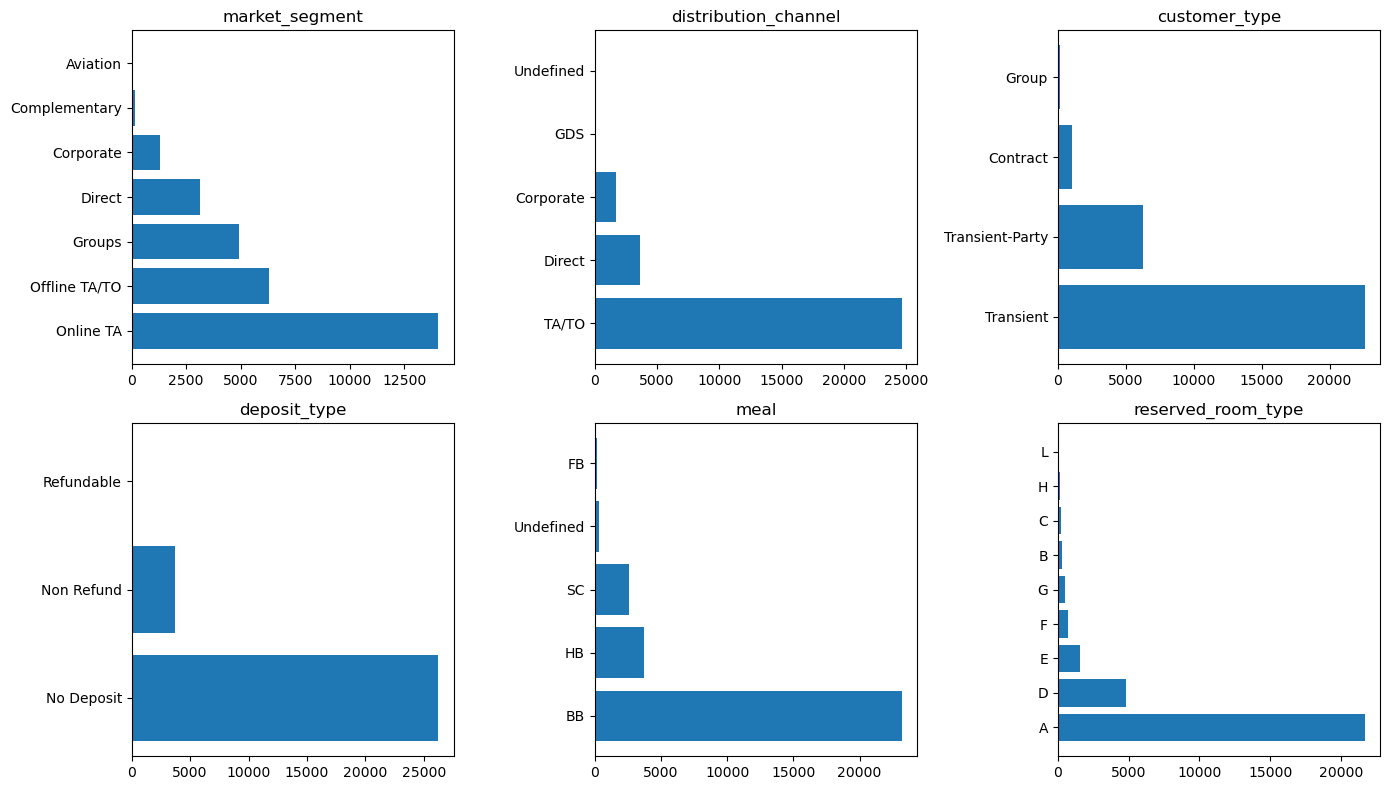

In [7]:
cat_features = [c for c in CATEGORICAL_FEATURES if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, cat_features):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values)
    ax.set_title(col)
for ax in axes.flat[len(cat_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## 4. Rare-Category Analysis


In [8]:
print(f"Rare-category threshold: {RARE_THRESHOLD:.0%}\n")
for col in cat_features:
    freq = df[col].value_counts(normalize=True).round(4)
    rare = freq[freq < RARE_THRESHOLD]
    if not rare.empty:
        print(f"{col}: {len(rare)} rare categories \u2192 grouped into 'Other'")
        print(rare.to_string(), "\n")
    else:
        print(f"{col}: no rare categories\n")


Rare-category threshold: 1%

market_segment: 2 rare categories → grouped into 'Other'
market_segment
Complementary    0.0056
Aviation         0.0023 

distribution_channel: 2 rare categories → grouped into 'Other'
distribution_channel
GDS          0.0016
Undefined    0.0000 

customer_type: 1 rare categories → grouped into 'Other'
customer_type
Group    0.0048 

deposit_type: 1 rare categories → grouped into 'Other'
deposit_type
Refundable    0.0015 

meal: 1 rare categories → grouped into 'Other'
meal
FB    0.0065 

reserved_room_type: 3 rare categories → grouped into 'Other'
reserved_room_type
C    0.0074
H    0.0049
L    0.0001 



## 5. Feature Correlation


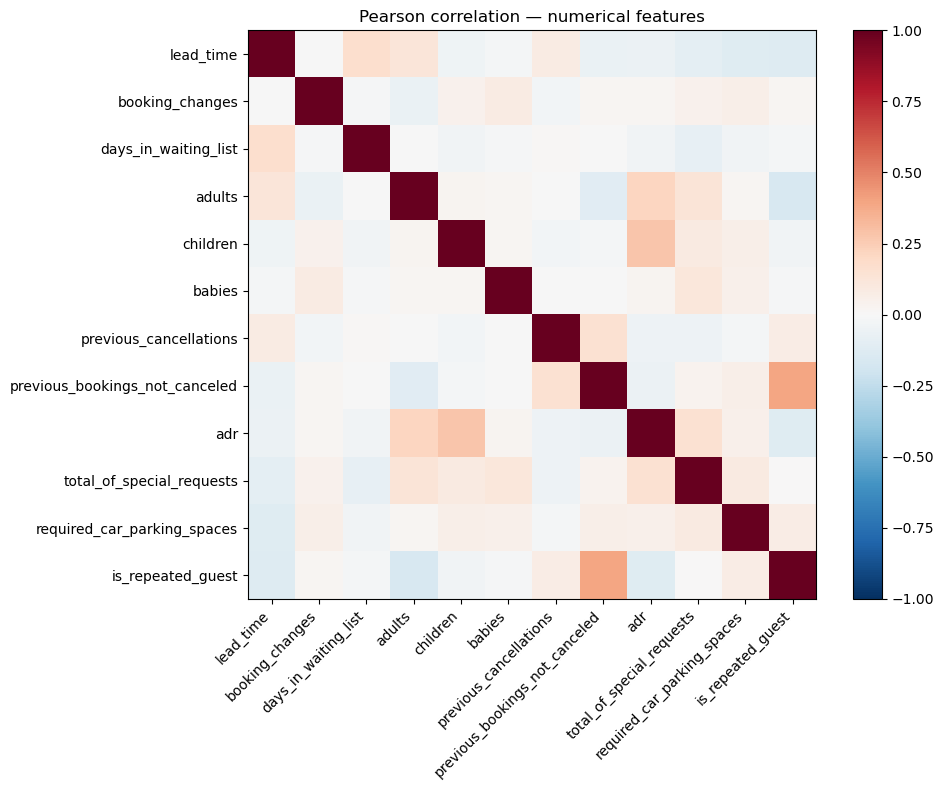

Top correlated pairs:
previous_bookings_not_canceled  is_repeated_guest                 0.391
children                        adr                               0.278
adults                          adr                               0.218
lead_time                       days_in_waiting_list              0.166
adults                          is_repeated_guest                 0.162
previous_cancellations          previous_bookings_not_canceled    0.156
adr                             total_of_special_requests         0.155
adults                          total_of_special_requests         0.131
lead_time                       is_repeated_guest                 0.129
                                required_car_parking_spaces       0.121
dtype: float64


In [9]:
num_df = df[[c for c in NUMERICAL_FEATURES if c in df.columns]].copy()
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
ax.set_title("Pearson correlation \u2014 numerical features")
plt.tight_layout()
plt.show()

pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("Top correlated pairs:")
print(pairs.head(10).round(3))


## 6. Segmentation Time

**Index time:** Booking creation. It is the moment the booking record is first created.

Under this choice, only information available when the booking is first recorded is
eligible as a clustering input.

**Excluded as clustering inputs (post-event / leakage):**
- `booking_changes`: counts changes made after initial booking; value is 0 at booking
  creation and accumulates over time
- `days_in_waiting_list`: similarly, not known at booking creation
- `is_canceled`, `reservation_status`, `assigned_room_type`: outcome/operational fields
  produced after booking creation

**Included via derived features:**
- `hotel` → `hotel_binary` (1 = Resort Hotel, 0 = City Hotel): property known at creation
- `arrival_date_month` → `arrival_month_sin`, `arrival_month_cos` (cyclic encoding):
  intended arrival month is chosen by the guest at booking time; cyclic encoding avoids
  imposing an arbitrary order (January ≠ close to December with raw month numbers)

**Controlled comparison:**
- `feature_set="no_context"` drops `hotel_binary`, `arrival_month_sin`, `arrival_month_cos`
  to test whether seasonality and hotel type drive the segmentation

In [ ]:
from src.preprocessing import EXCLUDED_COLUMNS, CONTEXT_BLOCK, FULL_FEATURE_SET

print("=== Excluded from clustering inputs ===")
for col in EXCLUDED_COLUMNS:
    print(f"  {col}")

print("\n=== Context features derived at booking creation ===")
for col in CONTEXT_BLOCK:
    print(f"  {col}")

print("\n=== Full feature set (clustering inputs) ===")
for col in FULL_FEATURE_SET:
    print(f"  {col}")


X_full, names_full = preprocess_data(df, feature_set="full", scaler="standard")
X_nocontext, names_nocontext = preprocess_data(df, feature_set="no_context", scaler="standard")
print(f"\nfull representation: {X_full.shape[1]} features")
print(f"no_context representation: {X_nocontext.shape[1]} features")
print(f"context columns in full: {[n for n in names_full if n in CONTEXT_BLOCK]}")

## 7. Distance Metric and Scaling Analysis


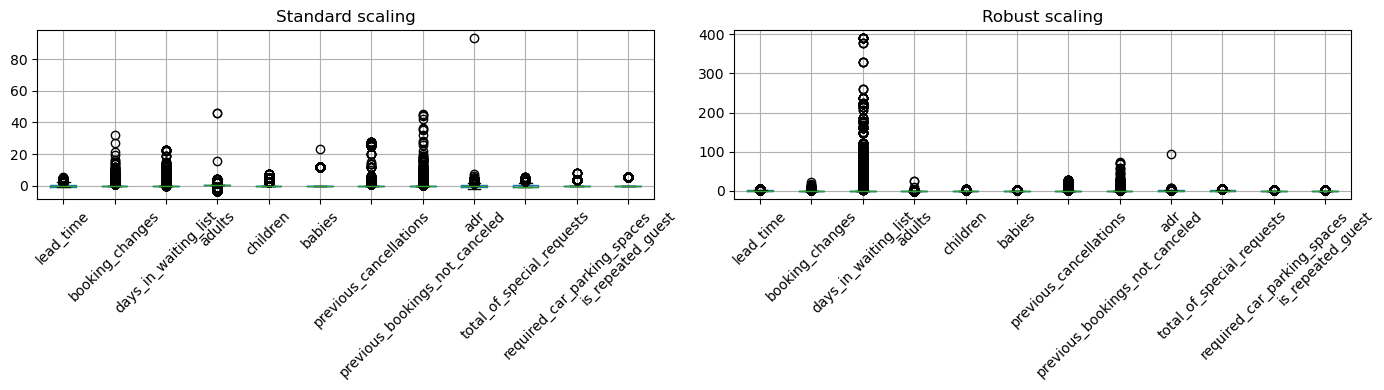

AttributeError: 'float' object has no attribute 'round'

In [10]:
from sklearn.preprocessing import StandardScaler, RobustScaler

num_df = df[[c for c in NUMERICAL_FEATURES if c in df.columns]].fillna(0)

std_scaled = pd.DataFrame(
    StandardScaler().fit_transform(num_df), columns=num_df.columns
)
rob_scaled = pd.DataFrame(
    RobustScaler().fit_transform(num_df), columns=num_df.columns
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
std_scaled.boxplot(ax=axes[0], rot=45)
axes[0].set_title("Standard scaling")
rob_scaled.boxplot(ax=axes[1], rot=45)
axes[1].set_title("Robust scaling")
plt.tight_layout()
plt.show()
print("Standard \u2014 max |mean|:", std_scaled.mean().abs().max().round(4))
print("Robust   \u2014 max |median|:", (rob_scaled.median()).abs().max().round(4))


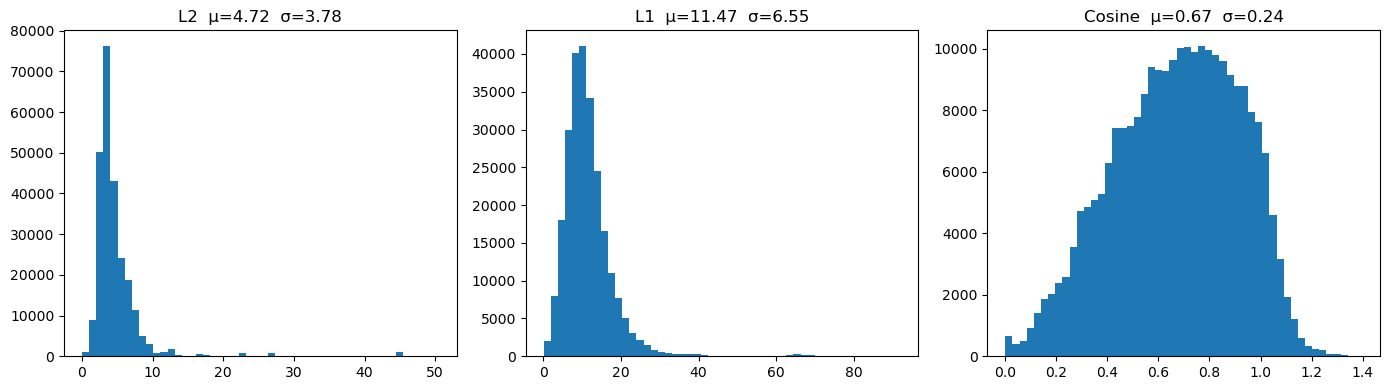

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

X_std, _ = preprocess_data(df, feature_set="full", scaler="standard")
rng = np.random.default_rng(42)
idx = rng.choice(len(X_std), size=500, replace=False)
X_sample = X_std[idx]

d_l2 = euclidean_distances(X_sample).ravel()
d_l1 = manhattan_distances(X_sample).ravel()
d_cos = cosine_distances(X_sample).ravel()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, d, label in zip(axes, [d_l2, d_l1, d_cos], ["L2", "L1", "Cosine"]):
    ax.hist(d[d > 0], bins=50)
    ax.set_title(f"{label}  \u03bc={d[d>0].mean():.2f}  \u03c3={d[d>0].std():.2f}")
plt.tight_layout()
plt.show()


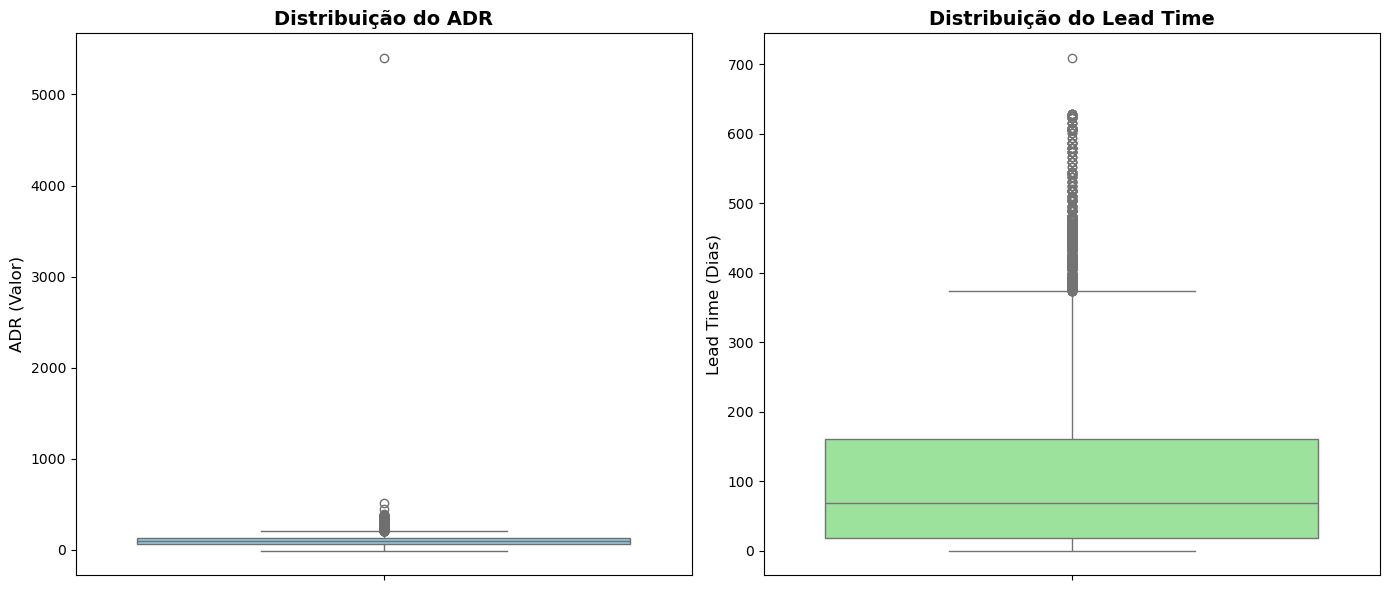

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2. Criar o primeiro boxplot (para o ADR)
sns.boxplot(y=df['adr'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição do ADR', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ADR (Valor)', fontsize=12)

# 3. Criar o segundo boxplot (para o Lead Time)
sns.boxplot(y=df['lead_time'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribuição do Lead Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Lead Time (Dias)', fontsize=12)

plt.tight_layout()
plt.show()